In [37]:
import torch
import matplotlib.pyplot as plt
import matplotlib.axes as axis
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn as nn
from torchinfo import summary
import statistics
import csv

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [39]:
all, middle_region, southern_region, northern_region = ([] for _ in range(4))
unassigned = 0
with open('embedding_dataset.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader) #skips first line of csv with headers
    for line in reader:
        match line[4]:
            case 'Eastern Temperate Forests':
                middle_region.append(line)
                all.append(line)
            case 'Northwestern Forested Mountains':
                northern_region.append(line)
                all.append(line)
            case 'Temperate Sierras':
                southern_region.append(line)
                all.append(line)
            case 'Great Plains':
                middle_region.append(line)
                all.append(line)
            case 'North American Deserts':
                southern_region.append(line)
                all.append(line)
            case 'Northern Forests':
                northern_region.append(line)
                all.append(line)
            case 'Mediterranean California':
                southern_region.append(line)
                all.append(line)
            case 'Marine West Coast Forests':
                northern_region.append(line)
                all.append(line)
            case 'Tropical Humid Forests':
                southern_region.append(line)
                all.append(line)
            case 'Southern Semi-Arid Highlands':
                northern_region.append(line)
                all.append(line)
            case _:
                all.append(line)
                unassigned += 1
                # print('unplanned classification')

In [40]:
length = len(all)
print(len(northern_region))
print(len(middle_region))
print(len(southern_region))
print(unassigned)

13076
24619
11670
262


In [41]:
genus_toint_dict = {}
species_toint_dict = {}
family_toint_dict = {}
location_toint_dict = {}
genus_tostring_dict = {}
species_tostring_dict = {}
family_tostring_dict = {}
location_tostring_dict = {}

fencode = 0
gencode = 0
sencode = 0
lencode = 0

for entry in all:
    if not entry[0] in family_toint_dict:
        family_toint_dict[entry[0]] = fencode
        family_tostring_dict[fencode] = entry[0]
        fencode += 1
    if not entry[1] in genus_toint_dict:
        genus_toint_dict[entry[1]] = gencode
        genus_tostring_dict[gencode] = entry[1]
        gencode += 1
    if not entry[2] in species_toint_dict:
        species_toint_dict[entry[2]] = sencode
        species_tostring_dict[sencode] = entry[2]
        sencode += 1
    if not entry[4] in location_toint_dict:
        location_toint_dict[entry[4]] = lencode
        location_tostring_dict[lencode] = entry[4]
        lencode += 1
print(len(location_toint_dict))
print(len(genus_toint_dict))
print(len(species_toint_dict))
print(len(family_toint_dict))


11
44
242
5


In [42]:
def encode(dataset):
    family = []
    genus = []
    location = []
    species = []
    year = []
    embeddings_tensor = torch.zeros(len(dataset), 64)
    for i, entry in enumerate(dataset):
        family.append(family_toint_dict[entry[0]])
        genus.append(genus_toint_dict[entry[1]])
        species.append(species_toint_dict[entry[2]])
        year.append(int(entry[3]))
        location.append(location_toint_dict[entry[4]])
        embeddings_tensor[i] = torch.tensor(list(map(float, entry[6:])))

    family_tensor = torch.tensor(family)
    genus_tensor = torch.tensor(genus)
    species_tensor = torch.tensor(species)
    location_tensor = torch.tensor(location)
    year_tensor = torch.tensor(year)

    return family_tensor, genus_tensor, species_tensor, location_tensor, year_tensor, embeddings_tensor

In [43]:
a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor = encode(all)
n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor = encode(northern_region)
m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor = encode(middle_region)
s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor = encode(southern_region)

In [44]:
species_weight = np.array([0.0]*len(species_toint_dict))
label_count = len(species_toint_dict)
for entry in m_species_tensor:
    species_weight[entry] += 1.0

species_weight = torch.tensor(species_weight/length).to(device)

In [45]:
class embed_dataset(torch.utils.data.Dataset):
    def __init__(self, family, genus, species, location, year, embeddings):
        self.family = family
        self.genus = genus
        self.location = location
        self.year = year
        self.species = species
        self.embeddings = embeddings

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        family = self.family[idx]
        genus = self.genus[idx]
        location = self.location[idx]
        species = self.species[idx]
        label = torch.zeros(len(species_weight))
        label[species] = 1
        target = species
        year = self.year[idx]
        embedding = self.embeddings[idx]
        return label, embedding, target


# Create dataset splits
# Set up dataloader for batches
batch_size = 1
a_train_dataset = embed_dataset(a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor)
a_train_dataloader = DataLoader(a_train_dataset, batch_size=batch_size, shuffle=True)

n_train_dataset = embed_dataset(n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor)
n_train_dataloader = DataLoader(n_train_dataset, batch_size=batch_size, shuffle=True)

m_train_dataset = embed_dataset(m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor)
m_train_dataloader = DataLoader(m_train_dataset, batch_size=batch_size, shuffle=True)

s_train_dataset = embed_dataset(s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor)
s_train_dataloader = DataLoader(s_train_dataset, batch_size=batch_size, shuffle=True)

In [46]:
#define model parameters
class TransformerModel(nn.Module):
    def __init__(self, layers=1):
        super().__init__()
        self.t1 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t2 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t3 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, label_count)
        self.relu = nn.ReLU()
        self.layers = layers
    def forward(self, embedding):
        result = self.t3(self.t2(self.t1(embedding)))
        x = self.relu(self.l1(result))
        return self.l2(x)
class SimpleLinear2(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, 2048)
        self.l3 = nn.Linear(2048, 242)
        self.relu = nn.ReLU()

    def forward(self, embedding):
        x = self.relu(self.l1(embedding))
        x = self.relu(self.l2(x))
        return self.l3(x)

In [ ]:
import torch.optim as optim
def training(model, learning_rate, criterion, train_dataloader):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    losses = []
    for epoch in range(10):
        model.train()
        total_loss = 0
        for label, embedding, target in train_dataloader:
            embedding, label = embedding.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(embedding)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")
    return losses

In [49]:
import torch.optim as optim
accuracies = []
labels = []
learning_rate = 2e-3

linear2 = SimpleLinear2().to(device)
transformer_a = TransformerModel().to(device)
transformer_n = TransformerModel().to(device)
transformer_m = TransformerModel().to(device)
transformer_s = TransformerModel().to(device)


criterion = nn.CrossEntropyLoss()
losses2 = training(model=linear2, learning_rate=learning_rate, criterion=criterion, train_dataloader=a_train_dataloader)
losses_a = training(model=transformer_a, learning_rate=learning_rate, criterion=criterion, train_dataloader=a_train_dataloader)
losses_n = training(model=transformer_n, learning_rate=learning_rate, criterion=criterion, train_dataloader=n_train_dataloader)
losses_m = training(model=transformer_m, learning_rate=learning_rate, criterion=criterion, train_dataloader=m_train_dataloader)
losses_s = training(model=transformer_s, learning_rate=learning_rate, criterion=criterion, train_dataloader=s_train_dataloader)

Epoch 1 - Loss: 2.214034
Epoch 2 - Loss: 1.960792
Epoch 3 - Loss: 1.925643
Epoch 4 - Loss: 1.903991
Epoch 5 - Loss: 1.888906
Epoch 6 - Loss: 1.882139
Epoch 7 - Loss: 1.874705
Epoch 8 - Loss: 1.880630
Epoch 9 - Loss: 1.874447
Epoch 10 - Loss: 1.868430
Epoch 1 - Loss: 4.759769
Epoch 2 - Loss: 4.734805
Epoch 3 - Loss: 4.735010
Epoch 4 - Loss: 4.732405
Epoch 5 - Loss: 4.736635
Epoch 6 - Loss: 4.734713
Epoch 7 - Loss: 4.733391
Epoch 8 - Loss: 4.731708
Epoch 9 - Loss: 4.734228
Epoch 10 - Loss: 4.733779
Epoch 1 - Loss: 3.893973
Epoch 2 - Loss: 3.825305
Epoch 3 - Loss: 3.811611
Epoch 4 - Loss: 3.807409
Epoch 5 - Loss: 3.808368
Epoch 6 - Loss: 3.809234
Epoch 7 - Loss: 3.808094
Epoch 8 - Loss: 3.807006
Epoch 9 - Loss: 3.805712
Epoch 10 - Loss: 3.805152
Epoch 1 - Loss: 4.148496
Epoch 2 - Loss: 4.104086
Epoch 3 - Loss: 4.104262
Epoch 4 - Loss: 4.105344
Epoch 5 - Loss: 4.105204
Epoch 6 - Loss: 4.102323
Epoch 7 - Loss: 4.101109
Epoch 8 - Loss: 4.100971
Epoch 9 - Loss: 4.096798
Epoch 10 - Loss: 4.098

In [55]:
def analyze(model, dataloader):
    count = 0
    with torch.no_grad():
        for label, embedding, target in dataloader:
            embedding, label, target = embedding.to(device), label.to(device), target.to(device)
            logits = model(embedding)
            predict = nn.Softmax()
            prediction = predict(logits)
            if(torch.argmax(prediction) == target):
                count += 1
    print(count, len(dataloader))
    print(count/len(dataloader))
    return count/len(dataloader)

In [56]:
analyze(linear2, a_train_dataloader)
accuracies.append(analyze(transformer_a, a_train_dataloader))
accuracies.append(analyze(transformer_n, n_train_dataloader))
accuracies.append(analyze(transformer_m, m_train_dataloader))
accuracies.append(analyze(transformer_s, s_train_dataloader))

/home/april/final_deep/lib/python3.12/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


22121 49627
0.4457452596368912
988 49627
0.019908517540854778
988 13076
0.07555827470174366
965 24619
0.03919736788659166
885 11670
0.07583547557840617


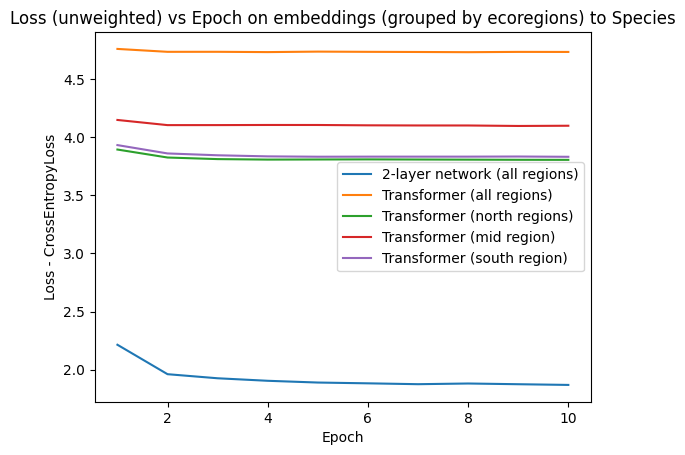

In [68]:
x = list(range(1,11))

plt.plot(x, losses2, label = "2-layer network (all regions)")
plt.plot(x, losses_a, label = "Transformer (all regions)")
plt.plot(x, losses_n, label = "Transformer (north regions)")
plt.plot(x, losses_m, label = "Transformer (mid region)")
plt.plot(x, losses_s, label = "Transformer (south region)")
plt.ylabel("Loss - CrossEntropyLoss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Loss (unweighted) vs Epoch on embeddings (grouped by ecoregions) to Species")
plt.show()

Text(0.5, 1.0, 'Embeddings (grouped by ecoregions) to species (unweighted)')

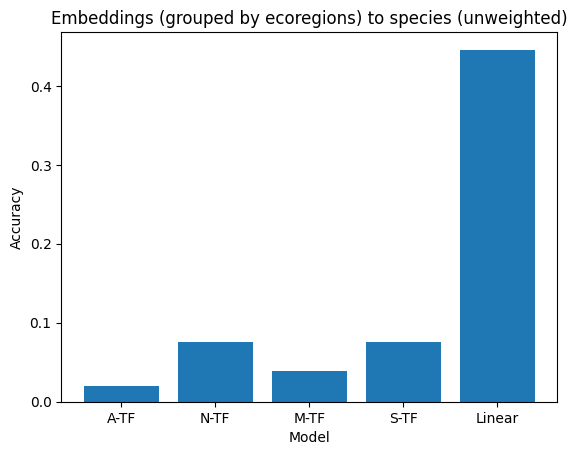

In [66]:
x = ["A-TF", "N-TF", "M-TF", "S-TF", "Linear"]
accuracies = [0.01990851754, 0.07555827470, 0.03919736788, 0.07583547557, 0.44574525963]
fig, ax = plt.subplots()
ax.bar(x, accuracies)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_title("Embeddings (grouped by ecoregions) to species (unweighted)")

In [69]:
class TransformerModelSimple(nn.Module):
    def __init__(self, layers=1):
        super().__init__()
        self.t1 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, label_count)
        self.relu = nn.ReLU()
        self.layers = layers
    def forward(self, embedding):
        result = self.t1(embedding)
        x = self.relu(self.l1(result))
        return self.l2(x)

In [70]:
simple_transformer_a = TransformerModelSimple().to(device)
simple_transformer_n = TransformerModelSimple().to(device)
simple_transformer_m = TransformerModelSimple().to(device)
simple_transformer_s = TransformerModelSimple().to(device)

losses_sa = training(model=simple_transformer_a, learning_rate=learning_rate, criterion=criterion, train_dataloader=a_train_dataloader)
losses_sn = training(model=simple_transformer_n, learning_rate=learning_rate, criterion=criterion, train_dataloader=n_train_dataloader)
losses_sm = training(model=simple_transformer_m, learning_rate=learning_rate, criterion=criterion, train_dataloader=m_train_dataloader)
losses_ss = training(model=simple_transformer_s, learning_rate=learning_rate, criterion=criterion, train_dataloader=s_train_dataloader)

Epoch 1 - Loss: 2.674253
Epoch 2 - Loss: 2.299819
Epoch 3 - Loss: 2.262625
Epoch 4 - Loss: 2.241936
Epoch 5 - Loss: 2.237654
Epoch 6 - Loss: 2.225539
Epoch 7 - Loss: 2.219231
Epoch 8 - Loss: 2.209372
Epoch 9 - Loss: 2.203444
Epoch 10 - Loss: 2.204816
Epoch 1 - Loss: 2.236753
Epoch 2 - Loss: 1.843452
Epoch 3 - Loss: 1.764583
Epoch 4 - Loss: 1.722320
Epoch 5 - Loss: 1.705257
Epoch 6 - Loss: 1.694912
Epoch 7 - Loss: 1.683172
Epoch 8 - Loss: 1.674417
Epoch 9 - Loss: 1.661684
Epoch 10 - Loss: 1.655658
Epoch 1 - Loss: 2.777520
Epoch 2 - Loss: 2.420286
Epoch 3 - Loss: 2.344310
Epoch 4 - Loss: 2.324665
Epoch 5 - Loss: 2.303660
Epoch 6 - Loss: 2.293083
Epoch 7 - Loss: 2.277764
Epoch 8 - Loss: 2.277532
Epoch 9 - Loss: 2.268273
Epoch 10 - Loss: 2.269183
Epoch 1 - Loss: 2.457033
Epoch 2 - Loss: 1.912117
Epoch 3 - Loss: 1.757423
Epoch 4 - Loss: 1.689282
Epoch 5 - Loss: 1.657381
Epoch 6 - Loss: 1.637944
Epoch 7 - Loss: 1.608350
Epoch 8 - Loss: 1.588401
Epoch 9 - Loss: 1.571444
Epoch 10 - Loss: 1.575

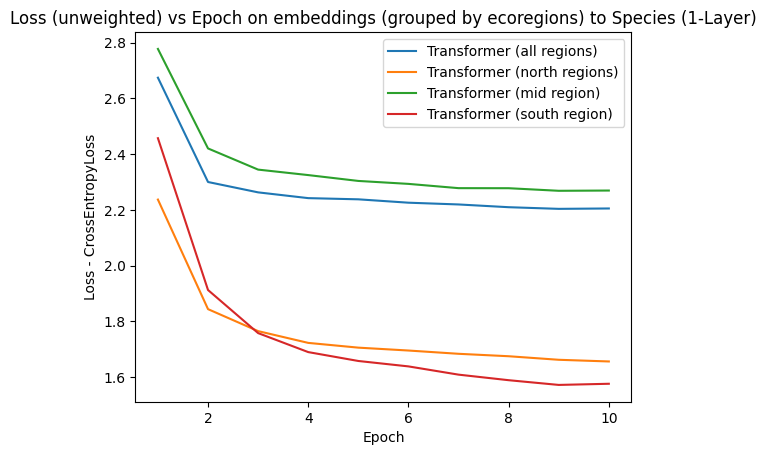

In [78]:
x = list(range(1,11))
plt.plot(x, losses_sa, label = "Transformer (all regions)")
plt.plot(x, losses_sn, label = "Transformer (north regions)")
plt.plot(x, losses_sm, label = "Transformer (mid region)")
plt.plot(x, losses_ss, label = "Transformer (south region)")
plt.ylabel("Loss - CrossEntropyLoss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Loss (unweighted) vs Epoch on embeddings (grouped by ecoregions) to Species (1-Layer)")
plt.show()

In [72]:
accuraciess = []
accuraciess.append(analyze(transformer_a, a_train_dataloader))
accuraciess.append(analyze(transformer_n, n_train_dataloader))
accuraciess.append(analyze(transformer_m, m_train_dataloader))
accuraciess.append(analyze(transformer_s, s_train_dataloader))

/home/april/final_deep/lib/python3.12/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


988 49627
0.019908517540854778
988 13076
0.07555827470174366
965 24619
0.03919736788659166
885 11670
0.07583547557840617


Text(0.5, 1.0, 'Embeddings (grouped by ecoregions) to species (unweighted) 1-Layer')

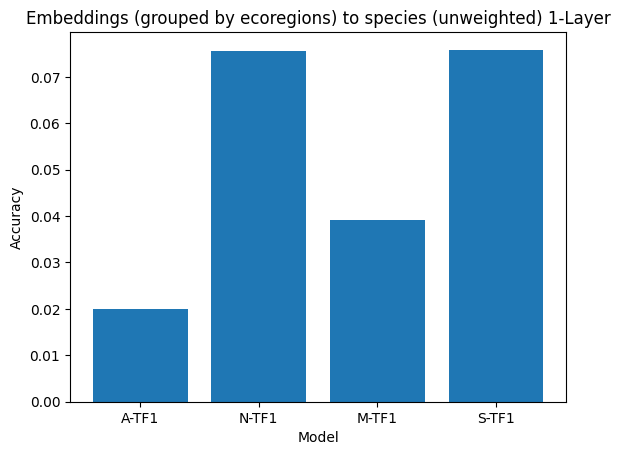

In [75]:
x = ["A-TF1", "N-TF1", "M-TF1", "S-TF1"]
fig, ax = plt.subplots()
ax.bar(x, accuraciess)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_title("Embeddings (grouped by ecoregions) to species (unweighted) 1-Layer")